# Immersed boundaries: SDF-based domain segmentation

The `pymrm` immersed-boundary tools specify conditions **per wall crossing**.
Unlike domain-wall boundary conditions, there is no natural way to broadcast a
value *along* an immersed wall.  For dispersed systems the pattern we usually
want is **piecewise constant per body**: give every particle its own surface or
interface condition.

`pymrm.segmentation` restores that workflow.  `segment_domain` labels the
disjoint regions of the signed distance field; `crossing_segments` tells you
which body each crossing bounds; and `segment_values` /
`combine_interface_conditions` expand per-body data to the per-crossing arrays
that `apply_ibm` / `apply_ibm_interface` consume.  Point data follows the
canonical shape `(n_crossings, *ns_shape)`, so per-component values broadcast
exactly like they do for wall boundary conditions.

In [1]:
import numpy as np
import scipy as sp
from scipy.sparse import csc_array
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from pymrm import (
    construct_grad, construct_div, construct_coefficient_matrix,
    construct_ibm, apply_ibm, apply_ibm_vector,
    construct_ibm_normal_derivative, apply_ibm_interface,
    segment_domain, crossing_segments, segment_values, segment_field,
    wall_contact, wall_patch, wall_values, combine_interface_conditions,
)

L, N = 1.0, 81
x_f = [np.linspace(0.0, L, N + 1), np.linspace(0.0, L, N + 1)]
x_c = [0.5 * (xf[:-1] + xf[1:]) for xf in x_f]
X, Y = np.meshgrid(x_c[0], x_c[1], indexing='ij')

def disk(cx, cy, r):
    return np.hypot(X - cx, Y - cy) - r

def diffusion_operator(shape, spatial_axes, D=1.0, cwall=0.0):
    '''div(-D grad) with zero-Dirichlet domain walls; returns (matrix, source).'''
    n = int(np.prod(shape))
    diff, g = csc_array((n, n)), np.zeros((n, 1))
    for i in spatial_axes:
        bc = ({'a': 0, 'b': 1, 'd': cwall}, {'a': 0, 'b': 1, 'd': cwall})
        gm, gb = construct_grad(shape, x_f[i], x_c[i], bc=bc, axis=i, format='csc')
        dv = construct_div(shape, x_f[i], axis=i, format='csc')
        diff = diff + dv @ (-D * gm)
        g = g + dv @ (-D * gb)
    return diff, np.asarray(g).reshape(-1)

## Three immersed bodies

Three well-separated disks in a fluid domain.  The SDF is the union (pointwise
minimum) of the three disk SDFs.

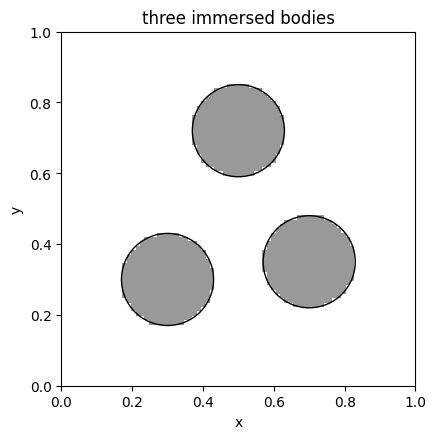

In [2]:
disks = [(0.30, 0.30, 0.13), (0.70, 0.35, 0.13), (0.50, 0.72, 0.13)]
sdf = np.full((N, N), np.inf)
for cx, cy, r in disks:
    sdf = np.minimum(sdf, disk(cx, cy, r))

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.pcolormesh(x_f[0], x_f[1], (sdf < 0).T, cmap='Greys', shading='flat', alpha=0.4)
for cx, cy, r in disks:
    ax.add_patch(Circle((cx, cy), r, fill=False, color='k'))
ax.set_aspect('equal'); ax.set_title('three immersed bodies'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.show()

## Segment the domain

`segment_domain(sdf)` labels the connected solid regions (`sdf < 0`) with
`scipy.ndimage.label`.  Face connectivity (`connectivity=1`, the default)
matches the staircase boundary of the IBM crossings.  `wall_contact` reports
which bodies reach a domain wall — here none do.

n_segments: 3   sizes: [347 351 348]


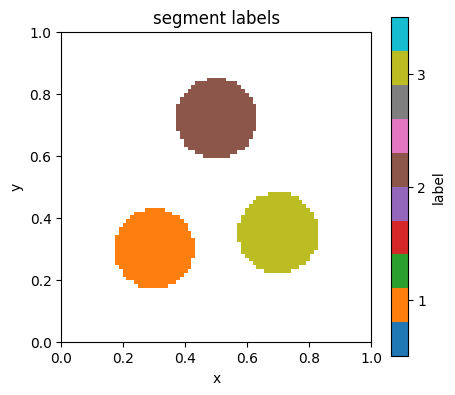

touches any domain wall: [False False False]


In [3]:
seg = segment_domain(sdf)
print('n_segments:', seg.n_segments, '  sizes:', seg.sizes)

fig, ax = plt.subplots(figsize=(5.0, 4.4))
m = ax.pcolormesh(x_f[0], x_f[1], np.ma.masked_equal(seg.labels, 0).T,
                  cmap='tab10', vmin=0.5, vmax=seg.n_segments + 0.5, shading='flat')
ax.set_aspect('equal'); ax.set_title('segment labels'); ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(m, ax=ax, ticks=range(1, seg.n_segments + 1), label='label')
plt.show()

print('touches any domain wall:', wall_contact(seg).any(axis=(1, 2)))

## Per-body Dirichlet condition

Hold each body at its own surface concentration.  `segment_values` maps the
`{label: value}` dictionary onto the crossings; `apply_ibm` then folds the
immersed Dirichlet condition into the diffusion operator.  The fluid diffuses
between the bodies and the zero-concentration domain walls.

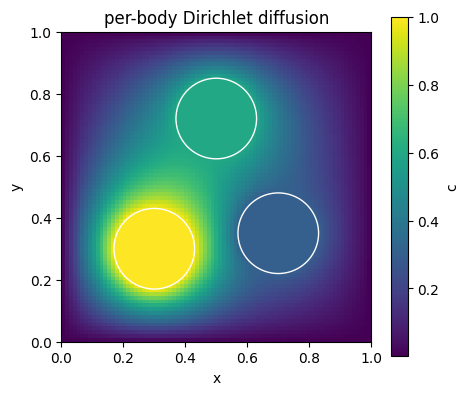

In [4]:
shape1 = (N, N)
ibm1 = construct_ibm(sdf, x_c, axes=(0, 1), shape=shape1)
diff, g_bc = diffusion_operator(shape1, (0, 1))

surf = segment_values({1: 1.0, 2: 0.6, 3: 0.3}, seg, ibm1)   # per-body surface value
A, g_wall = apply_ibm(diff, ibm1, values_outside=surf, values_inside=surf)
u = spsolve(A.tocsc(), apply_ibm_vector(-g_bc, ibm1) - g_wall)

fig, ax = plt.subplots(figsize=(5.0, 4.4))
m = ax.pcolormesh(x_f[0], x_f[1], u.reshape(shape1).T, shading='flat', cmap='viridis')
for cx, cy, r in disks:
    ax.add_patch(Circle((cx, cy), r, fill=False, color='w'))
ax.set_aspect('equal'); ax.set_title('per-body Dirichlet diffusion'); ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(m, ax=ax, label='c'); plt.show()

## Multi-dimensional broadcasting: per body *and* per component

With a component axis the point data has canonical shape
`(n_crossings, n_c)`.  A per-body value is now a length-`n_c` vector, and
`segment_values` broadcasts it over the crossings automatically — exactly the
broadcasting you get for wall boundary conditions.

per-body / per-component point values: (252, 2)


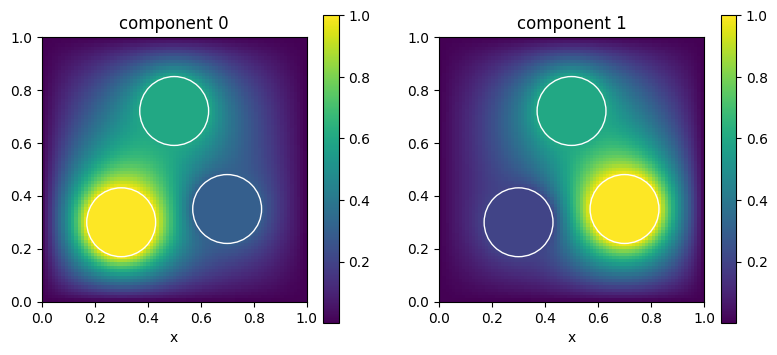

In [5]:
Nc = 2
shapeC = (N, N, Nc)
ibmC = construct_ibm(sdf, x_c, axes=(0, 1), shape=shapeC)
diffC, g_bcC = diffusion_operator(shapeC, (0, 1))

surfC = segment_values({1: [1.0, 0.2], 2: [0.6, 0.6], 3: [0.3, 1.0]}, seg, ibmC)
print('per-body / per-component point values:', surfC.shape)   # (n_crossings, Nc)

AC, g_wallC = apply_ibm(diffC, ibmC, values_outside=surfC, values_inside=surfC)
uC = spsolve(AC.tocsc(), apply_ibm_vector(-g_bcC, ibmC) - g_wallC).reshape(shapeC)

fig, axs = plt.subplots(1, Nc, figsize=(9.4, 4.0))
for k in range(Nc):
    m = axs[k].pcolormesh(x_f[0], x_f[1], uC[:, :, k].T, shading='flat', cmap='viridis')
    for cx, cy, r in disks:
        axs[k].add_patch(Circle((cx, cy), r, fill=False, color='w'))
    axs[k].set_aspect('equal'); axs[k].set_title(f'component {k}'); axs[k].set_xlabel('x')
    fig.colorbar(m, ax=axs[k])
plt.show()

## Per-body interface conditions (conjugate diffusion)

Give each body its own internal diffusivity `D_in` and partition coefficient
`K` and solve the **conjugate** problem across the interface.
`combine_interface_conditions` merges the per-body `ic` dictionaries into a
single per-crossing `ic` for `apply_ibm_interface`; `segment_field` builds the
matching cell-centred diffusivity.  A left→right gradient (`c=0` at `x=0`,
`c=1` at `x=1`) drives the transport.

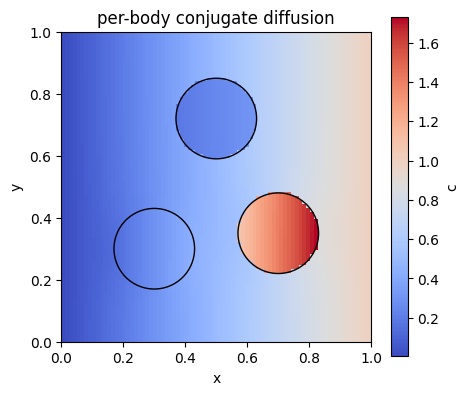

In [6]:
D_out = 1.0
body_ic = {
    1: ({'a': (D_out, 0.5), 'b': (0, 0), 'd': 0}, {'a': (0, 0), 'b': (1, -1.0), 'd': 0}),
    2: ({'a': (D_out, 2.0), 'b': (0, 0), 'd': 0}, {'a': (0, 0), 'b': (1, -2.0), 'd': 0}),
    3: ({'a': (D_out, 0.2), 'b': (0, 0), 'd': 0}, {'a': (0, 0), 'b': (1, -0.5), 'd': 0}),
}
ic = combine_interface_conditions(body_ic, seg, ibm1)
recon = construct_ibm_normal_derivative(ibm1, sdf, x_c)

# Cell-centred diffusivity: D_in inside each body, D_out in the fluid.
D_field = segment_field({1: 0.5, 2: 2.0, 3: 0.2}, seg, default=D_out)
D_mat = construct_coefficient_matrix(D_field, shape=shape1)

# Bare Laplacian with the driving gradient, then scale by the cell-centred D.
bcs = (({'a': 0, 'b': 1, 'd': 0.0}, {'a': 0, 'b': 1, 'd': 1.0}),
       ({'a': 1, 'b': 0, 'd': 0.0}, {'a': 1, 'b': 0, 'd': 0.0}))
Lap, g_lap = csc_array((N * N, N * N)), np.zeros((N * N, 1))
for i, bc in enumerate(bcs):
    gm, gb = construct_grad(shape1, x_f[i], x_c[i], bc=bc, axis=i, format='csc')
    dv = construct_div(shape1, x_f[i], axis=i, format='csc')
    Lap = Lap + dv @ gm
    g_lap = g_lap + dv @ gb
g_lap = np.asarray(g_lap).reshape(-1)
L_cc = -(D_mat @ Lap)
g_cc = -np.asarray(D_mat @ g_lap).reshape(-1)

A_ic, g_ic = apply_ibm_interface(L_cc, ibm1, recon, ic)
u_ic = spsolve(A_ic.tocsc(), apply_ibm_vector(-g_cc, ibm1) - g_ic).reshape(shape1)

fig, ax = plt.subplots(figsize=(5.0, 4.4))
m = ax.pcolormesh(x_f[0], x_f[1], u_ic.T, shading='flat', cmap='coolwarm')
for cx, cy, r in disks:
    ax.add_patch(Circle((cx, cy), r, fill=False, color='k'))
ax.set_aspect('equal'); ax.set_title('per-body conjugate diffusion'); ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(m, ax=ax, label='c'); plt.show()

## Domain-wall patches

Where a body intersects a domain wall, `wall_patch` returns the body labels on
that wall shaped as a full-field coefficient, and `wall_values` turns a
per-body value into a ready `{a, b, d}` coefficient.  This lets a wall-touching
body carry the same condition on its wall patch as on its immersed part.

wall contact per body [axis, (lower, upper)]:
[[[ True False]
  [False False]]

 [[False False]
  [False False]]]
patch shape (full-field rank): (1, 81, 1)  labels on x=0 wall: [1]
wall_values shape (BC coefficient): (1, 81, 2)


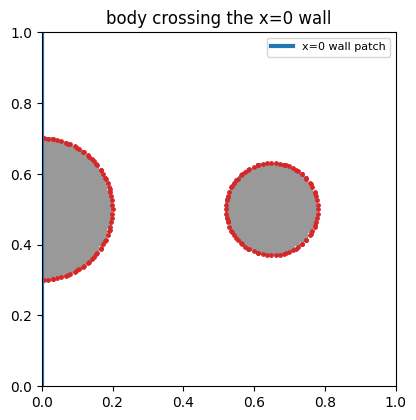

In [7]:
sdf_w = np.minimum(disk(0.0, 0.5, 0.20), disk(0.65, 0.5, 0.13))
seg_w = segment_domain(sdf_w)
ibm_w = construct_ibm(sdf_w, x_c, axes=(0, 1), shape=(N, N, Nc))

print('wall contact per body [axis, (lower, upper)]:')
print(wall_contact(seg_w))

patch = wall_patch(seg_w, ibm_w, axis=0, side='lower')
on_wall = np.unique(seg_w.labels[0]); on_wall = on_wall[on_wall > 0]
print('patch shape (full-field rank):', patch.shape, ' labels on x=0 wall:', on_wall)

wv = wall_values({int(on_wall[0]): [1.0, 0.4]}, seg_w, ibm_w, axis=0, side='lower')
print('wall_values shape (BC coefficient):', wv.shape)

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.pcolormesh(x_f[0], x_f[1], (sdf_w < 0).T, cmap='Greys', shading='flat', alpha=0.4)
ax.scatter(ibm_w.coords[:, 0], ibm_w.coords[:, 1], s=6, c='tab:red')
ax.axvline(0.0, color='tab:blue', lw=3, label='x=0 wall patch')
ax.set_aspect('equal'); ax.set_title('body crossing the x=0 wall'); ax.legend(fontsize=8)
plt.show()

## Isolated-pocket detection

On the **fluid** side (`region="positive"`), a segment that touches no domain
wall is an enclosed pocket.  With all-Neumann surroundings such a pocket makes
the operator singular, so it is worth detecting up front.  Here a solid ring
encloses one fluid pocket.

fluid segments: 2   isolated pocket labels: [2]


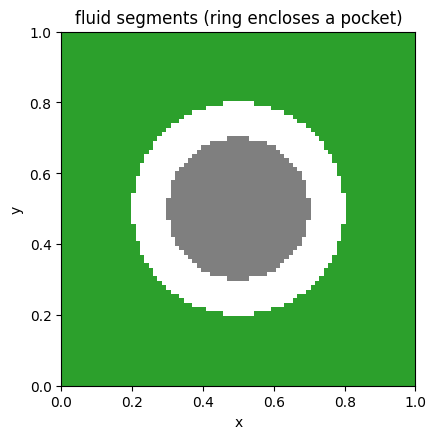

In [8]:
r = np.hypot(X - 0.5, Y - 0.5)
sdf_ring = np.abs(r - 0.25) - 0.05                      # solid ring 0.20 < r < 0.30
seg_pos = segment_domain(sdf_ring, region='positive')
contact = wall_contact(seg_pos).any(axis=(1, 2))
pockets = np.flatnonzero(~contact) + 1
print('fluid segments:', seg_pos.n_segments, '  isolated pocket labels:', pockets)

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.pcolormesh(x_f[0], x_f[1], np.ma.masked_equal(seg_pos.labels, 0).T,
              cmap='tab10', vmin=0.5, vmax=seg_pos.n_segments + 0.5, shading='flat')
ax.set_aspect('equal'); ax.set_title('fluid segments (ring encloses a pocket)')
ax.set_xlabel('x'); ax.set_ylabel('y'); plt.show()